##Part 1
### Извлечение и обработка навыков

In [6]:
!pip -q install spacy razdel natasha scikit-learn pandas numpy matplotlib rapidfuzz

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 152.1 MB/s eta 0:00:00
  ERROR: HTTP error 404 while getting https://github.com/explosion/spacy-models/releases/download/-ru_core_news_sm/-ru_core_news_sm.tar.gz
ERROR: Could not install requirement https://github.com/explosion/spacy-models/releases/download/-ru_core_news_sm/-ru_core_news_sm.tar.gz because of HTTP error 404 Client Error: Not Found for url: https://github.com/explosion/spacy-models/releases/download/-ru_core_news_sm/-ru_core_news_sm.tar.gz for URL https://github.com/explosion/spacy-models/releases/download/-ru_core_news_sm/-ru_core_news_sm.tar.gz


In [5]:
import spacy, sys, subprocess
minor = ".".join(spacy.__version__.split(".")[:2])   # например, '3.7'
url = f"https://github.com/explosion/spacy-models/releases/download/ru_core_news_sm-{minor}.0/ru_core_news_sm-{minor}.0-py3-none-any.whl"
print("Installing:", url)
subprocess.check_call([sys.executable, "-m", "pip", "install", url])

import spacy
nlp = spacy.load("ru_core_news_sm")
print("OK:", nlp.pipe_names)


Installing: https://github.com/explosion/spacy-models/releases/download/ru_core_news_sm-3.7.0/ru_core_news_sm-3.7.0-py3-none-any.whl
OK: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [6]:
import json, re, os, math, itertools
from collections import defaultdict, Counter
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd

# NLP
try:
    import spacy
    nlp = spacy.load("ru_core_news_sm")
    SPACY_OK = True
except Exception as e:
    print("⚠️ spaCy ru_core_news_sm недоступна, работаем без лингвистики. Причина:", e)
    nlp = None
    SPACY_OK = False

from razdel import sentenize

# --- Natasha pipeline for Russian (noun-like phrases + NER) ---
from natasha import (
    Segmenter, NewsEmbedding, NewsMorphTagger, NewsNERTagger, NewsSyntaxParser, Doc
)

SEGMENTER = Segmenter()
EMB = NewsEmbedding()
MORPH = NewsMorphTagger(EMB)
NER = NewsNERTagger(EMB)
SYNTAX = NewsSyntaxParser(EMB)

def natasha_phrases(text: str):
    """
    Кандидаты фраз на основе Natasha:
    - NER-спаны (ORG/MISC/PRODUCT часто ловят названия технологий)
    - короткие последовательности с POS ∈ {NOUN, PROPN, ADJ} длиной 1–3
    """
    doc = Doc(text)
    doc.segment(SEGMENTER)
    doc.tag_morph(MORPH)
    doc.tag_ner(NER)
    doc.parse_syntax(SYNTAX)

    spans = set()

    # NER
    for span in doc.spans:
        spans.add(span.text.strip())

    # Простые noun-последовательности
    seq = []
    def flush_seq():
        if 1 <= len(seq) <= 3:
            spans.add(" ".join(seq))
        seq.clear()

    for token in doc.tokens:
        pos = (token.pos or "").upper()
        tok = token.text.strip()
        if pos in {"NOUN","PROPN","ADJ"} and tok:
            seq.append(tok)
        else:
            flush_seq()
    flush_seq()

    return list(spans)

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from rapidfuzz import fuzz, process

# === Пути к файлам (лежат рядом с ноутбуком) ===
CORPUS_PATH = "skills_gap_seed_DE_ru20.jsonl"
DICT_PATH   = "skills_dict_DE_ru.json"

# === Загрузка корпуса ===
records = []
with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

print(f"Загружено записей: {len(records)} | Пример ключей:", records[0].keys())

# === Загрузка словаря ===
with open(DICT_PATH, "r", encoding="utf-8") as f:
    SKILLS_DICT = json.load(f)

ROLES = list(SKILLS_DICT.keys())
print("Роли в словаре:", ROLES)

Загружено записей: 20 | Пример ключей: dict_keys(['id', 'type', 'lang', 'role', 'text', 'skills_gold'])
Роли в словаре: ['Data Scientist', 'Data Engineer', 'Data Analyst']


In [7]:
# --- Нормализация текста ---
def normalize_text(s: str) -> str:
    s = s.replace("\xa0", " ")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\u2013|\u2014", "-", s)  # длинные тире -> дефис
    return s.strip()

# --- Детект секций (упрощённый) ---
SECTION_PATTERNS = {
    "cv": {
        "skills": re.compile(r"(?im)^(навыки|skills)\s*:"),
        "experience": re.compile(r"(?im)^(опыт|experience)\s*:"),
    },
    "job": {
        "must": re.compile(r"(?im)^(обязательные|must-?have|требования)\s*:"),
        "nice": re.compile(r"(?im)^(плюсом|желательно|nice-?to-?have)\s*:"),
    },
}

def detect_sections(text: str, rec_type: str):
    """
    Возвращает список (start, end, label), где label ∈ {skills, experience, must, nice}
    Упрощённое: ищем заголовки-строки и тянем до следующего заголовка или конца.
    """
    lines = [ln for ln in normalize_text(text).splitlines()]
    spans = []
    current = None

    def label_for(line):
        for name, pat in SECTION_PATTERNS.get(rec_type, {}).items():
            if pat.search(line):
                return name
        return None

    for i, ln in enumerate(lines):
        lab = label_for(ln)
        if lab:
            # закрываем предыдущий
            if current:
                spans.append((current["start"], i, current["label"]))
            current = {"start": i, "label": lab}
    if current:
        spans.append((current["start"], len(lines), current["label"]))

    # вернём плоский текст отрезков
    out = []
    for s, e, lab in spans:
        chunk = "\n".join(lines[s:e])
        out.append((s, e, lab, chunk))
    return out

# --- Сбор всех канонов и алиасов в быстрые lookup-структуры ---
def build_skill_maps(skills_dict: Dict):
    role_to_canonical = {role: set(v["canonical"]) for role, v in skills_dict.items()}
    role_to_alias_map = {}
    for role, v in skills_dict.items():
        alias_map = {}
        # алиасы → канон
        for a, c in v.get("aliases", {}).items():
            alias_map[a.lower()] = c
        # каноны → канон (для удобства)
        for c in v["canonical"]:
            alias_map[c.lower()] = c
        role_to_alias_map[role] = alias_map
    return role_to_canonical, role_to_alias_map

ROLE2CANON, ROLE2ALIAS = build_skill_maps(SKILLS_DICT)

def normalize_skill_token(tok: str, role: str) -> str | None:
    """Приводим найденный токен к canonical по ROLE2ALIAS; None если не распознали."""
    if not tok:
        return None
    key = tok.strip().lower()
    return ROLE2ALIAS.get(role, {}).get(key)

In [8]:
# Подготовим корпус текстов
corpus_texts = [normalize_text(r["text"]) for r in records]

# TF-IDF по уни/би/три-граммам
VECTORIZER = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,3),
    min_df=1,
    max_df=0.9,
    lowercase=False,   # важно для аббревиатур и названий
)

X = VECTORIZER.fit_transform(corpus_texts)
feature_names = np.array(VECTORIZER.get_feature_names_out())

# простой фильтр «похоже на навык»
TECH_LIKE = re.compile(r"[A-Za-z0-9][A-Za-z0-9\-\./\+]+")  # Python, PySpark, A/B, scikit-learn, ClickHouse...

def candidates_tfidf_pos(text: str, lang: str, top_k: int = 30) -> List[str]:
    """
    Берём top-k n-грамм по TF-IDF из документа и оставляем тех-похожие.
    Для RU не используем spaCy noun_chunks (их нет в ru_core_news_sm), работаем по TF-IDF + TECH_LIKE.
    """
    txt = normalize_text(text)
    vec = VECTORIZER.transform([txt])
    idx = vec.nonzero()[1]
    scores = vec.toarray()[0, idx]
    top_idx = idx[np.argsort(-scores)[:top_k]]
    ngrams = feature_names[top_idx]

    cands = [ng for ng in ngrams if TECH_LIKE.search(ng)]

    # Если когда-то будет EN-модель со spaCy — можно включить noun_chunks/ents,
    # но для RU это отключаем (иначе падение).
    # if SPACY_OK and lang != "ru":
    #     doc = nlp(txt)
    #     valid_spans = set()
    #     for np_chunk in doc.noun_chunks:
    #         valid_spans.add(np_chunk.text.strip())
    #     for t in doc:
    #         if t.pos_ in {"PROPN","NOUN","ADJ"}:
    #             valid_spans.add(t.text.strip())
    #     cands = [c for c in cands if any(c in vs for vs in valid_spans)]

    cands = [c.strip() for c in cands if len(c.strip()) >= 2]
    return list(dict.fromkeys(cands))

In [9]:
def compile_role_patterns(role: str):
    """
    Компилируем регексы для канонов и алиасов данной роли.
    Поиск без учёта регистра; границы слова учитываем гибко (латиница/кириллица/знаки).
    """
    alias_map = ROLE2ALIAS.get(role, {})
    patterns = {}
    for alias_lower, canon in alias_map.items():
        # экранируем специальные символы, но позволяем слэши/плюсы/дефисы
        pat = re.escape(alias_lower).replace(r"\ ", r"\s+")
        patterns[alias_lower] = (canon, re.compile(rf"(?i)(?<!\w){pat}(?!\w)"))
    return patterns

ROLE2PATS = {role: compile_role_patterns(role) for role in ROLES}

def candidates_dictionary(text: str, role: str) -> List[str]:
    txt = normalize_text(text)
    outs = []
    for alias_lower, (canon, pat) in ROLE2PATS.get(role, {}).items():
        if pat.search(txt):
            outs.append(canon)
    # уникализируем
    return list(dict.fromkeys(outs))

In [10]:
def candidates_linguistic(text: str, role: str) -> List[str]:
    """
    RU: используем Natasha (NER + noun-phrases по POS), затем фильтруем тех-термины и нормализуем по словарю.
    non-RU: (на будущее) можно дергать spaCy noun_chunks/ents, но в этом проекте всё RU.
    """
    txt = normalize_text(text)

    # Русский путь — Natasha
    spans = natasha_phrases(txt)

    # оставляем тех-похожие токены/фразы (латиница/цифры/+,./-)
    spans = [s for s in spans if TECH_LIKE.search(s)]

    # нормализация через словарь (алиасы -> каноны)
    out = []
    for s in spans:
        canon = normalize_skill_token(s, role)
        if canon:
            out.append(canon)
    # уникализируем
    return list(dict.fromkeys(out))

In [11]:
def normalize_and_merge(role: str, cands_by_method: Dict[str, List[str]], text: str, rec_type: str):
    """
    cands_by_method: {"tfidf": [...], "dict": [...], "ling": [...]}
    -> список объектов: {name, source, importance, in_skills_section, score}
    """
    # 1) нормализация: tfidf и ling уже нормальные/канонизированные,
    #    словарь даёт каноны сразу; но tfidf может выдавать «сырые» n-граммы — дожмём:
    merged = defaultdict(lambda: {"name": None, "source": set(), "importance": None, "in_skills_section": False})
    alias_map = ROLE2ALIAS.get(role, {})

    def add_tokens(tokens, method):
        for t in tokens:
            canon = normalize_skill_token(t, role) or alias_map.get(t.lower())
            if not canon:
                continue
            d = merged[canon]
            d["name"] = canon
            d["source"].add(method)

    add_tokens(cands_by_method.get("dict", []), "dict")
    add_tokens(cands_by_method.get("ling", []), "ling")
    add_tokens(cands_by_method.get("tfidf", []), "tfidf")

    # 2) тэги важности по секциям
    sections = detect_sections(text, rec_type)
    text_skills_block = ""
    importance_map = {}
    for _, _, lab, chunk in sections:
        if rec_type == "job" and lab in {"must","nice"}:
            # пометим все найденные внутри этого куска, грубо: если подстрока встречается — "важность"
            for canon in list(merged.keys()):
                if re.search(rf"(?i)\b{re.escape(canon)}\b", chunk):
                    importance_map[canon] = "must" if lab == "must" else "nice"
        if rec_type == "cv" and lab == "skills":
            text_skills_block += "\n" + chunk

    # отметим importance и попадание в «Навыки» у CV
    for canon, d in merged.items():
        d["importance"] = importance_map.get(canon)
        if rec_type == "cv" and text_skills_block:
            d["in_skills_section"] = bool(re.search(rf"(?i)\b{re.escape(canon)}\b", text_skills_block))

    # 3) скоринг: базовый + бонусы
    out = []
    for canon, d in merged.items():
        score = 0.6  # базовый
        # бонус за ансамбль
        score += 0.1 * (len(d["source"]) - 1)  # 0.1 за каждый доп. метод
        # важность JD
        if d["importance"] == "must":
            score += 0.3
        elif d["importance"] == "nice":
            score += 0.1
        # явное упоминание в секции «Навыки» для CV
        if d["in_skills_section"]:
            score += 0.1

        out.append({
            "name": canon,
            "source": sorted(list(d["source"])),
            "importance": d["importance"],
            "in_skills_section": d["in_skills_section"],
            "score": round(score, 3)
        })
    # сортировка по score
    out.sort(key=lambda x: (-x["score"], x["name"]))
    return out

In [12]:
def extract_skills_record(rec: Dict, role_hint: str | None = None):
    role = role_hint or rec["role"]
    text = rec["text"]
    rec_type = rec["type"]  # "cv" | "job"
    lang = rec.get("lang","ru")

    c_tfidf = candidates_tfidf_pos(text, lang, top_k=40)
    c_dict  = candidates_dictionary(text, role)
    c_ling  = candidates_linguistic(text, role)

    merged = normalize_and_merge(
        role=role,
        cands_by_method={"tfidf": c_tfidf, "dict": c_dict, "ling": c_ling},
        text=text,
        rec_type=rec_type
    )
    return merged, {"tfidf": c_tfidf, "dict": c_dict, "ling": c_ling}

In [13]:
def evaluate_on_records(recs: List[Dict], role_hint: str | None = None):
    rows = []
    for r in recs:
        pred_list, raw = extract_skills_record(r, role_hint=role_hint)
        pred = {x["name"] for x in pred_list}
        gold = set(r.get("skills_gold", []))

        tp = len(pred & gold)
        fp = len(pred - gold)
        fn = len(gold - pred)

        precision = tp / (tp + fp) if (tp+fp)>0 else 0.0
        recall    = tp / (tp + fn) if (tp+fn)>0 else 0.0
        f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0

        rows.append({
            "id": r["id"], "type": r["type"], "role": r["role"],
            "precision": round(precision,3), "recall": round(recall,3), "f1": round(f1,3),
            "tp": tp, "fp": fp, "fn": fn,
            "n_pred": len(pred), "n_gold": len(gold)
        })
    df = pd.DataFrame(rows)
    # агрегаты
    agg_all = df[["precision","recall","f1"]].mean().to_dict()
    agg_cv  = df[df.type=="cv"][["precision","recall","f1"]].mean().to_dict()
    agg_jd  = df[df.type=="job"][["precision","recall","f1"]].mean().to_dict()
    return df, {"ALL": agg_all, "CV": agg_cv, "JD": agg_jd}

In [14]:
# Пример для просмотра
sample = records[0]
merged, raw = extract_skills_record(sample)
print("=== SAMPLE:", sample["id"], sample["role"], sample["type"])
print("\nRaw candidates:")
for k,v in raw.items():
    print(f"  {k}: {v[:15]}{'...' if len(v)>15 else ''}")

print("\nMerged & scored:")
for obj in merged[:15]:
    print(obj)

# Оценка по всему корпусу
df_metrics, summary = evaluate_on_records(records)
print("\n=== Сводка по метрикам (среднее):")
for k,v in summary.items():
    print(k, {m: round(val,3) for m,val in v.items()})

print("\nTOP-10 строк метрик:")
display(df_metrics.sort_values("f1", ascending=False).head(10))

=== SAMPLE: cv_ds_ru_001 Data Scientist cv

Raw candidates:
  tfidf: ['CatBoost', '12', 'Манна Уитни CUPED', 'uplift конверсии CatBoost', 'uplift конверсии', 'uplift', 'товаров AUC', 'learn CatBoost XGBoost', 'bootstrap Образование МФТИ', 'bootstrap Образование', 'bootstrap', 'Иван Петров Data', 'Петров Data', 'Петров Data Scientist', 'спроса MAPE 12']...
  dict: ['Python', 'pandas', 'numpy', 'scikit-learn', 'LightGBM', 'CatBoost', 'SQL', 'PostgreSQL', 'Airflow', 'Docker', 'Git', 'MLflow']
  ling: ['Airflow', 'CatBoost', 'SQL', 'Git', 'Docker', 'MLflow', 'PostgreSQL']

Merged & scored:
{'name': 'CatBoost', 'source': ['dict', 'ling', 'tfidf'], 'importance': None, 'in_skills_section': True, 'score': 0.9}
{'name': 'Airflow', 'source': ['dict', 'ling'], 'importance': None, 'in_skills_section': True, 'score': 0.8}
{'name': 'Docker', 'source': ['dict', 'ling'], 'importance': None, 'in_skills_section': True, 'score': 0.8}
{'name': 'Git', 'source': ['dict', 'ling'], 'importance': None, 'in_ski

,id,type,role,precision,recall,f1,tp,fp,fn,n_pred,n_gold
16,cv_da_ru_012,cv,Data Analyst,1.000,1.000,1.000,10,0,0,10,10
12,jd_de_ru_105,job,Data Engineer,0.938,1.000,0.968,15,1,0,16,15
1,cv_ds_ru_004,cv,Data Scientist,1.000,0.933,0.966,14,0,1,14,15
18,jd_da_ru_106,job,Data Analyst,1.000,0.933,0.966,14,0,1,14,15
10,cv_de_ru_011,cv,Data Engineer,0.929,1.000,0.963,13,1,0,14,13
5,jd_ds_ru_104,job,Data Scientist,1.000,0.929,0.963,13,0,1,13,14
14,cv_da_ru_003,cv,Data Analyst,0.929,1.000,0.963,13,1,0,14,13
17,jd_da_ru_103,job,Data Analyst,1.000,0.923,0.960,12,0,1,12,13
19,jd_da_ru_108,job,Data Analyst,1.000,0.909,0.952,10,0,1,10,11
3,cv_ds_ru_008,cv,Data Scientist,1.000,0.909,0.952,10,0,1,10,11


In [15]:
out_jsonl = "extracted_skills_ru20.jsonl"
with open(out_jsonl, "w", encoding="utf-8") as f:
    for r in records:
        merged, raw = extract_skills_record(r)
        f.write(json.dumps({
            "id": r["id"], "type": r["type"], "role": r["role"],
            "skills": merged, "gold": r.get("skills_gold", [])
        }, ensure_ascii=False) + "\n")

print("Записал:", out_jsonl)

Записал: extracted_skills_ru20.jsonl


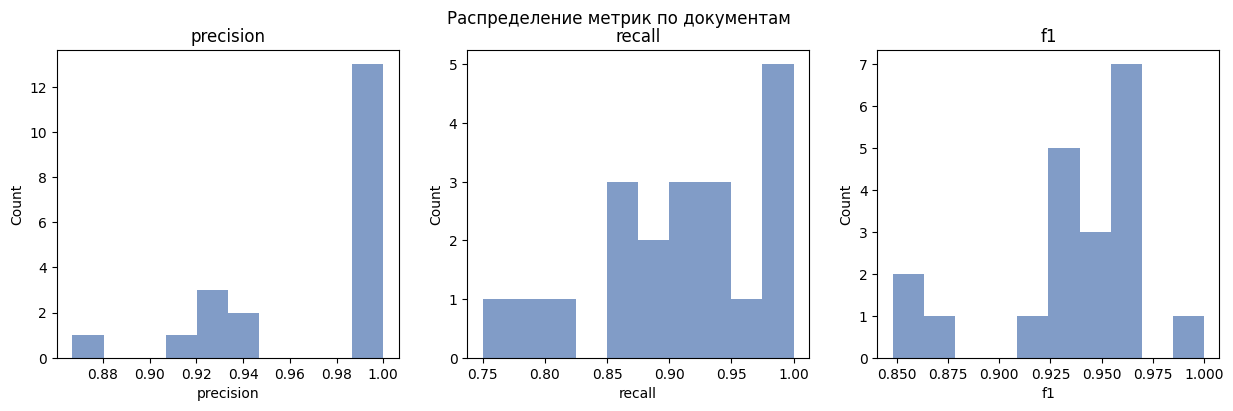

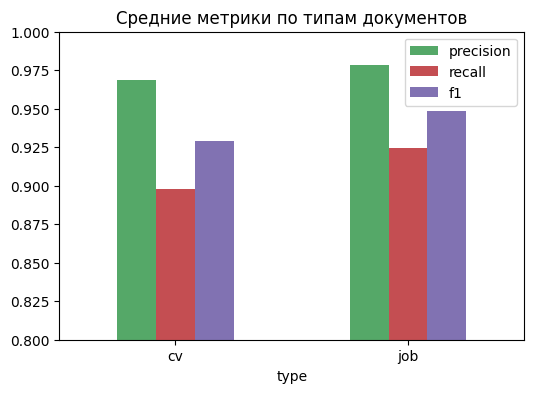

In [16]:
import matplotlib.pyplot as plt

# Гистограммы распределений
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, m in enumerate(["precision", "recall", "f1"]):
    axes[i].hist(df_metrics[m], bins=10, color="#4C72B0", alpha=0.7)
    axes[i].set_title(m)
    axes[i].set_xlabel(m)
    axes[i].set_ylabel("Count")
plt.suptitle("Распределение метрик по документам")
plt.show()

# Сравнение типов документов
df_metrics.groupby("type")[["precision","recall","f1"]].mean().plot(
    kind="bar", figsize=(6,4), title="Средние метрики по типам документов",
    color=["#55A868","#C44E52","#8172B2"]
)
plt.xticks(rotation=0)
plt.ylim(0.8,1)
plt.show()

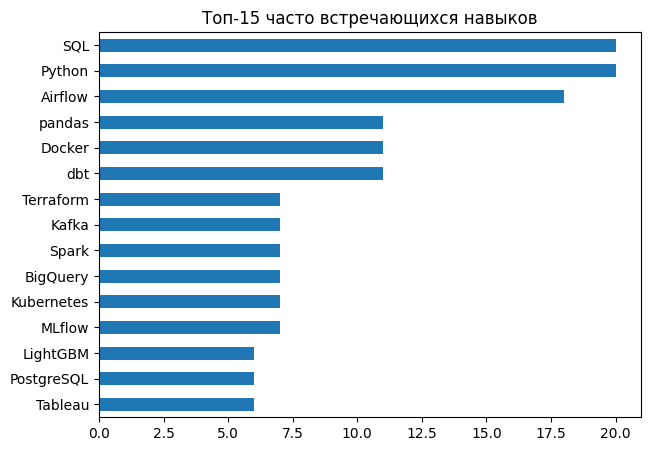

In [17]:
from collections import Counter
all_skills = Counter()
for r in records:
    merged, _ = extract_skills_record(r)
    for s in merged:
        all_skills[s["name"]] += 1

pd.Series(all_skills).sort_values(ascending=False).head(15).plot(
    kind="barh", figsize=(7,5), title="Топ-15 часто встречающихся навыков"
)
plt.gca().invert_yaxis()
plt.show()

## PART 2
### Semantik matching

In [23]:
!pip -q install sentence-transformers > /dev/null

In [25]:
import json, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import List, Dict, Tuple
from collections import defaultdict

# Fallback похожести
from rapidfuzz import fuzz

# Эмбеддинги (опционально)
try:
    from sentence_transformers import SentenceTransformer
    SBERT = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    USE_EMB = True
except Exception as e:
    print("⚠️ sentence-transformers недоступен, используем RapidFuzz fallback. Причина:", e)
    SBERT, USE_EMB = None, False


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [18]:
# Соберём по каждому документу: навыки, текст, тип, роль
rec2skills: Dict[str, List[str]] = {}
rec2text:   Dict[str, str] = {}
rec2type:   Dict[str, str] = {}
rec2role:   Dict[str, str] = {}

for r in records:
    merged, _ = extract_skills_record(r)                 # твоя функция
    skills = [x["name"] for x in merged]                 # канонические имена
    rec2skills[r["id"]] = skills
    rec2text[r["id"]]   = r["text"]
    rec2type[r["id"]]   = r["type"]      # "cv" | "job"
    rec2role[r["id"]]   = r["role"]


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# — 3.1: какой ключ является «паровым»?
PAIR_KEYS = ["pair_id", "pair", "group_id", "pairId", "pid"]
detected_pair_key = None
for k in PAIR_KEYS:
    if any(k in r for r in records):
        detected_pair_key = k
        break

# — 3.2: группируем документы
groups = defaultdict(lambda: {"cv": [], "job": []})
if detected_pair_key:
    for r in records:
        key = r.get(detected_pair_key)
        if key is None:
            key = f"role:{r['role']}"
        groups[key][r["type"]].append(r["id"])
else:
    # fallback: по ролям
    for r in records:
        key = f"role:{r['role']}"
        groups[key][r["type"]].append(r["id"])

def greedy_pair_by_tfidf(cv_ids: List[str], jd_ids: List[str]) -> List[Tuple[str,str]]:
    if not cv_ids or not jd_ids:
        return []
    docs = [rec2text[i] for i in cv_ids] + [rec2text[j] for j in jd_ids]
    vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5)).fit(docs)
    A = vec.transform([rec2text[i] for i in cv_ids])
    B = vec.transform([rec2text[j] for j in jd_ids])
    sim = cosine_similarity(A, B)  # |cv| x |jd|

    taken_cv, taken_jd = set(), set()
    pairs = []
    # жадно берём максимум, пока возможно
    while len(taken_cv) < len(cv_ids) and len(taken_jd) < len(jd_ids):
        i, j = divmod(sim.argmax(), sim.shape[1])
        if i in taken_cv or j in taken_jd or sim[i, j] < -0.5:
            sim[i, j] = -1.0
            continue
        pairs.append((cv_ids[i], jd_ids[j]))
        taken_cv.add(i); taken_jd.add(j)
        sim[i, :] = -1.0
        sim[:, j] = -1.0
    return pairs

# — 3.3: строим итоговый список пар
pairs_list = []
for gkey, bucket in groups.items():
    cvs, jds = bucket["cv"], bucket["job"]
    if len(cvs) == 1 and len(jds) == 1:
        pairs_list.append((cvs[0], jds[0], gkey))
    else:
        for (cv_id, jd_id) in greedy_pair_by_tfidf(cvs, jds):
            pairs_list.append((cv_id, jd_id, gkey))

print(f"Всего пар для сопоставления: {len(pairs_list)}")


Всего пар для сопоставления: 9


In [20]:
def jaccard(a: List[str], b: List[str]) -> float:
    A, B = set(a), set(b)
    if not A and not B:
        return 0.0
    return len(A & B) / max(1, len(A | B))

def tfidf_cosine_on_skills(a: List[str], b: List[str]) -> float:
    s1 = " ; ".join(sorted(set(a)))
    s2 = " ; ".join(sorted(set(b)))
    if not s1 and not s2:
        return 0.0
    vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5)).fit([s1, s2])
    X = vec.transform([s1, s2])
    return float(cosine_similarity(X[0], X[1])[0,0])

def pairwise_matrix(skills_a: List[str], skills_b: List[str]) -> np.ndarray:
    if not skills_a or not skills_b:
        return np.zeros((len(skills_a), len(skills_b)), dtype="float32")
    if USE_EMB:
        A = SBERT.encode(skills_a, normalize_embeddings=True)
        B = SBERT.encode(skills_b, normalize_embeddings=True)
        # Косинус для нормированных = скалярное произведение
        return (A @ B.T).astype("float32")
    else:
        M = np.zeros((len(skills_a), len(skills_b)), dtype="float32")
        for i, a in enumerate(skills_a):
            for j, b in enumerate(skills_b):
                M[i, j] = fuzz.WRatio(a, b) / 100.0
        return M

def symmetric_best_avg(M: np.ndarray) -> float:
    if M.size == 0:
        return 0.0
    row_best = M.max(axis=1).mean() if M.shape[1] > 0 else 0.0
    col_best = M.max(axis=0).mean() if M.shape[0] > 0 else 0.0
    return float((row_best + col_best) / 2)

def topk_pairs(M: np.ndarray, skills_a: List[str], skills_b: List[str], k: int = 5):
    if M.size == 0:
        return []
    used_i, used_j = set(), set()
    out = []
    flat = [(float(M[i, j]), i, j) for i in range(M.shape[0]) for j in range(M.shape[1])]
    for score, i, j in sorted(flat, key=lambda x: -x[0]):
        if i in used_i or j in used_j:
            continue
        out.append((skills_a[i], skills_b[j], float(score)))
        used_i.add(i); used_j.add(j)
        if len(out) >= k:
            break
    return out


In [26]:
summary_rows = []
top5_rows = []

for cv_id, jd_id, gkey in pairs_list:
    role = rec2role[cv_id]
    sk_cv = rec2skills.get(cv_id, [])
    sk_jd = rec2skills.get(jd_id, [])

    # Матрица похожести и метрики
    M = pairwise_matrix(sk_cv, sk_jd)
    avg_sim = symmetric_best_avg(M)
    jacc   = jaccard(sk_cv, sk_jd)
    tfidf  = tfidf_cosine_on_skills(sk_cv, sk_jd)
    top5   = topk_pairs(M, sk_cv, sk_jd, k=5)

    summary_rows.append({
        "pair_group": gkey,
        "cv_id": cv_id, "jd_id": jd_id, "role": role,
        "n_cv": len(sk_cv), "n_jd": len(sk_jd),
        "avg_sim": round(avg_sim, 4),
        "jaccard": round(jacc, 4),
        "tfidf_cos": round(tfidf, 4),
        "top5_preview": "; ".join([f"{a} ↔ {b} ({s:.2f})" for a,b,s in top5])
    })
    for a, b, s in top5:
        top5_rows.append({"pair_group": gkey, "cv_id": cv_id, "jd_id": jd_id,
                          "role": role, "cv_skill": a, "jd_skill": b, "score": round(s, 4)})

df_match = pd.DataFrame(summary_rows).sort_values("avg_sim", ascending=False)
df_top5  = pd.DataFrame(top5_rows)

print("=== Итоговая таблица (head) ===")
display(df_match.head(10))

# Сохранение
OUT_DIR = "skill_matching_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
df_match.to_csv(f"{OUT_DIR}/skill_matching_summary.csv", index=False)
df_top5.to_csv(f"{OUT_DIR}/skill_matching_top5.csv", index=False)

print(f"Saved:\n- {OUT_DIR}/skill_matching_summary.csv\n- {OUT_DIR}/skill_matching_top5.csv")


=== Итоговая таблица (head) ===


,pair_group,cv_id,jd_id,role,n_cv,n_jd,avg_sim,jaccard,tfidf_cos,top5_preview
6,role:Data Analyst,cv_da_ru_003,jd_da_ru_103,Data Analyst,14,12,0.9490,0.8571,0.8695,PostgreSQL ↔ PostgreSQL (1.00); SQL ↔ SQL (1.0...
7,role:Data Analyst,cv_da_ru_006,jd_da_ru_106,Data Analyst,12,14,0.9165,0.7333,0.8163,PostgreSQL ↔ PostgreSQL (1.00); SQL ↔ SQL (1.0...
5,role:Data Engineer,cv_de_ru_011,jd_de_ru_105,Data Engineer,14,16,0.9057,0.6667,0.8029,SQL ↔ SQL (1.00); Spark ↔ Spark (1.00); CDC ↔ ...
4,role:Data Engineer,cv_de_ru_010,jd_de_ru_107,Data Engineer,15,15,0.8908,0.6667,0.7725,BigQuery ↔ BigQuery (1.00); Spark ↔ Spark (1.0...
2,role:Data Scientist,cv_ds_ru_007,jd_ds_ru_109,Data Scientist,15,8,0.8520,0.5333,0.6972,MLflow ↔ MLflow (1.00); SQL ↔ SQL (1.00); Tran...
3,role:Data Engineer,cv_de_ru_002,jd_de_ru_102,Data Engineer,24,20,0.8381,0.5172,0.7919,Docker ↔ Docker (1.00); CI/CD ↔ CI/CD (1.00); ...
0,role:Data Scientist,cv_ds_ru_008,jd_ds_ru_101,Data Scientist,10,13,0.8376,0.5333,0.7037,CatBoost ↔ CatBoost (1.00); Airflow ↔ Airflow ...
8,role:Data Analyst,cv_da_ru_012,jd_da_ru_108,Data Analyst,10,10,0.8237,0.5385,0.6660,Grafana ↔ Grafana (1.00); Tableau ↔ Tableau (1...
1,role:Data Scientist,cv_ds_ru_004,jd_ds_ru_104,Data Scientist,14,13,0.7862,0.4211,0.6105,Docker ↔ Docker (1.00); MLflow ↔ MLflow (1.00)...


Saved:
- skill_matching_outputs/skill_matching_summary.csv
- skill_matching_outputs/skill_matching_top5.csv


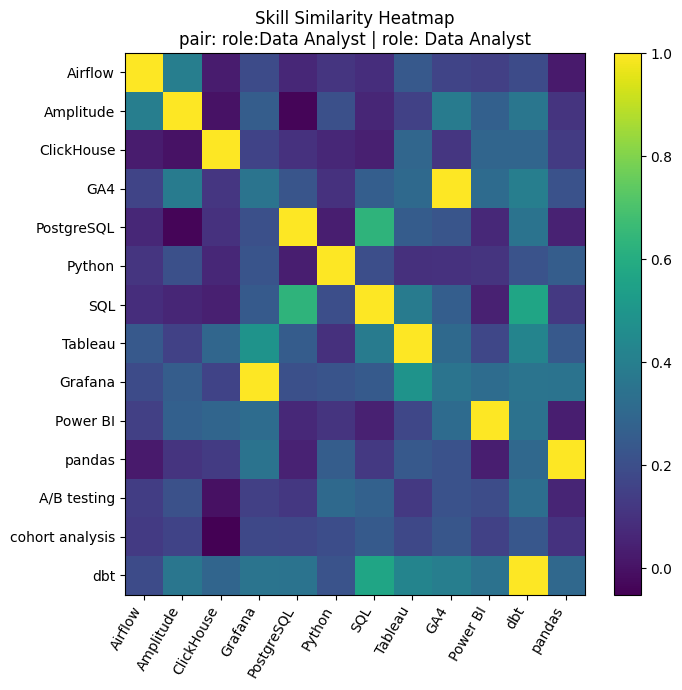

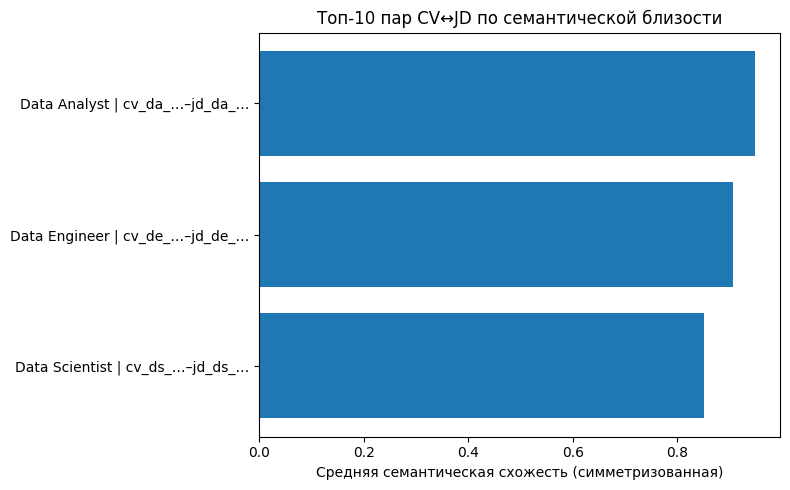

In [27]:
# Выберем «лучшую» пару для heatmap
if not df_match.empty:
    best_row = df_match.iloc[0]
    cv_id, jd_id = best_row.cv_id, best_row.jd_id
    sk_cv = rec2skills.get(cv_id, [])
    sk_jd = rec2skills.get(jd_id, [])
    # ограничим размеры, чтобы подписи влезли
    sk_cv_hm = sk_cv[:15]
    sk_jd_hm = sk_jd[:15]
    M_hm = pairwise_matrix(sk_cv_hm, sk_jd_hm)

    plt.figure(figsize=(max(6, len(sk_jd_hm)*0.6), max(4, len(sk_cv_hm)*0.5)))
    plt.imshow(M_hm, aspect="auto")
    plt.xticks(range(len(sk_jd_hm)), sk_jd_hm, rotation=60, ha="right")
    plt.yticks(range(len(sk_cv_hm)), sk_cv_hm)
    plt.colorbar()
    plt.title(f"Skill Similarity Heatmap\npair: {best_row.pair_group} | role: {best_row.role}")
    plt.tight_layout()
    plt.show()

# Bar-chart: топ-10 пар по средней семантической схожести
if not df_match.empty:
    topk_pairs_df = df_match.head(10).copy()
    plt.figure(figsize=(8, 5))
    plt.barh([f"{r.role} | {r.cv_id[:6]}…–{r.jd_id[:6]}…" for _, r in topk_pairs_df.iterrows()],
             topk_pairs_df["avg_sim"])
    plt.gca().invert_yaxis()
    plt.xlabel("Средняя семантическая схожесть (симметризованная)")
    plt.title("Топ-10 пар CV↔JD по семантической близости")
    plt.tight_layout()
    plt.show()


##Part 3
### Анализ разрыва (GAP)

In [28]:
# Semantics-based gap detection

from typing import Dict, List, Tuple

# удобные индексы по id
id2rec = {r["id"]: r for r in records}

def jd_skills_with_importance(jd_id: str) -> List[Tuple[str, float]]:
    """
    Возвращает список (skill, weight) для JD.
    Вес: must=1.0, nice=0.7, прочее=0.5
    """
    rec = id2rec[jd_id]
    merged, _ = extract_skills_record(rec)
    out = []
    for x in merged:
        w = 0.5
        if x.get("importance") == "must":
            w = 1.0
        elif x.get("importance") == "nice":
            w = 0.7
        out.append((x["name"], w))
    return out

def compute_gap_for_pair(cv_id: str, jd_id: str, tau: float = 0.65):
    """
    Семантическое покрытие JD-навыков резюме.
    - matched_pairs: список (cv_skill, jd_skill, score) для пар с score >= tau (жадно, 1-к-1)
    - missing_jd: JD-навыки, чей max score < tau
    - score_raw: простая метрика coverage = |covered JD| / |JD|
    - score_weighted: покрытие с весами must/nice/other
    """
    cv_sk = rec2skills.get(cv_id, [])
    jd_sk = rec2skills.get(jd_id, [])

    # матрица похожести
    M = pairwise_matrix(cv_sk, jd_sk)

    # best match для каждого JD-скилла
    covered = []
    best_pair_for_jd = []
    for j, jd_name in enumerate(jd_sk):
        if len(cv_sk) == 0:
            best = 0.0; i_best = None
        else:
            i_best = int(np.argmax(M[:, j])) if M.shape[0] else None
            best = float(M[i_best, j]) if i_best is not None else 0.0
        covered.append(best >= tau)
        best_pair_for_jd.append((i_best, j, best))

    # список недостающих навыков JD
    missing_jd = [jd_sk[j] for j, ok in enumerate(covered) if not ok]

    # метрика coverage (raw)
    score_raw = (sum(covered) / len(jd_sk)) if jd_sk else 1.0

    # метрика coverage с весами important/nice/other
    jd_w = dict(jd_skills_with_importance(jd_id))  # skill -> weight
    total_w = sum(jd_w.get(s, 0.5) for s in jd_sk) or 1.0
    covered_w = sum(jd_w.get(jd_sk[j], 0.5) for j, ok in enumerate(covered) if ok)
    score_weighted = covered_w / total_w

    # Top-k жадный (без повторов) — используем уже существующую утилиту
    top5 = topk_pairs(M, cv_sk, jd_sk, k=5)

    return {
        "cv_id": cv_id, "jd_id": jd_id,
        "role": rec2role[cv_id],
        "tau": tau,
        "matched_pairs": top5,
        "missing_jd": missing_jd,
        "score_raw": float(score_raw),
        "score_weighted": float(score_weighted),
        "n_cv": len(cv_sk), "n_jd": len(jd_sk)
    }


In [29]:
# Attach coverage/gap columns to df_match

def attach_gap_columns(df_match_in: pd.DataFrame, tau: float = 0.65) -> pd.DataFrame:
    rows = []
    for _, r in df_match_in.iterrows():
        g = compute_gap_for_pair(r.cv_id, r.jd_id, tau=tau)
        rows.append({
            "cv_id": r.cv_id, "jd_id": r.jd_id,
            "coverage_sem": round(g["score_raw"], 4),
            "coverage_sem_w": round(g["score_weighted"], 4),
            "missing_count": len(g["missing_jd"]),
            "missing_preview": "; ".join(g["missing_jd"][:8]),
            "matched_preview2": "; ".join([f"{a}↔{b}({s:.2f})" for a,b,s in g["matched_pairs"]])
        })
    add = pd.DataFrame(rows)
    merged = df_match_in.merge(add, on=["cv_id","jd_id"], how="left")
    return merged

df_match_ext = attach_gap_columns(df_match, tau=0.65).sort_values(["coverage_sem_w","avg_sim"], ascending=False)
display(df_match_ext.head(10))

# Сохраним расширенную сводку
os.makedirs("skill_matching_outputs", exist_ok=True)
df_match_ext.to_csv("skill_matching_outputs/skill_matching_summary_with_gap.csv", index=False)
print("Saved: skill_matching_outputs/skill_matching_summary_with_gap.csv")


,pair_group,cv_id,jd_id,role,n_cv,n_jd,avg_sim,jaccard,tfidf_cos,top5_preview,coverage_sem,coverage_sem_w,missing_count,missing_preview,matched_preview2
0,role:Data Analyst,cv_da_ru_003,jd_da_ru_103,Data Analyst,14,12,0.9490,0.8571,0.8695,PostgreSQL ↔ PostgreSQL (1.00); SQL ↔ SQL (1.0...,1.0000,1.0000,0,,PostgreSQL↔PostgreSQL(1.00); SQL↔SQL(1.00); Cl...
4,role:Data Scientist,cv_ds_ru_007,jd_ds_ru_109,Data Scientist,15,8,0.8520,0.5333,0.6972,MLflow ↔ MLflow (1.00); SQL ↔ SQL (1.00); Tran...,1.0000,1.0000,0,,MLflow↔MLflow(1.00); SQL↔SQL(1.00); Transforme...
2,role:Data Engineer,cv_de_ru_011,jd_de_ru_105,Data Engineer,14,16,0.9057,0.6667,0.8029,SQL ↔ SQL (1.00); Spark ↔ Spark (1.00); CDC ↔ ...,0.8125,0.8456,3,Debezium; Snowflake; BigQuery,SQL↔SQL(1.00); Spark↔Spark(1.00); CDC↔CDC(1.00...
3,role:Data Engineer,cv_de_ru_010,jd_de_ru_107,Data Engineer,15,15,0.8908,0.6667,0.7725,BigQuery ↔ BigQuery (1.00); Spark ↔ Spark (1.0...,0.8000,0.8182,3,Structured Streaming; AWS; Snowflake,BigQuery↔BigQuery(1.00); Spark↔Spark(1.00); SQ...
1,role:Data Analyst,cv_da_ru_006,jd_da_ru_106,Data Analyst,12,14,0.9165,0.7333,0.8163,PostgreSQL ↔ PostgreSQL (1.00); SQL ↔ SQL (1.0...,0.7857,0.7939,3,BigQuery; R; Grafana,PostgreSQL↔PostgreSQL(1.00); SQL↔SQL(1.00); Ta...
5,role:Data Engineer,cv_de_ru_002,jd_de_ru_102,Data Engineer,24,20,0.8381,0.5172,0.7919,Docker ↔ Docker (1.00); CI/CD ↔ CI/CD (1.00); ...,0.7500,0.7328,5,Azure; Flink; Snowflake; BigQuery; GCP,Docker↔Docker(1.00); CI/CD↔CI/CD(1.00); Spark↔...
7,role:Data Analyst,cv_da_ru_012,jd_da_ru_108,Data Analyst,10,10,0.8237,0.5385,0.6660,Grafana ↔ Grafana (1.00); Tableau ↔ Tableau (1...,0.7000,0.7000,3,Airflow; Power BI; dbt,Grafana↔Grafana(1.00); Tableau↔Tableau(1.00); ...
8,role:Data Scientist,cv_ds_ru_004,jd_ds_ru_104,Data Scientist,14,13,0.7862,0.4211,0.6105,Docker ↔ Docker (1.00); MLflow ↔ MLflow (1.00)...,0.6154,0.6696,5,TensorFlow; ranking; recsys; CatBoost; Feast,Docker↔Docker(1.00); MLflow↔MLflow(1.00); Ligh...
6,role:Data Scientist,cv_ds_ru_008,jd_ds_ru_101,Data Scientist,10,13,0.8376,0.5333,0.7037,CatBoost ↔ CatBoost (1.00); Airflow ↔ Airflow ...,0.6154,0.6197,5,Feast; Docker; Git; PyTorch; TensorFlow,CatBoost↔CatBoost(1.00); Airflow↔Airflow(1.00)...


Saved: skill_matching_outputs/skill_matching_summary_with_gap.csv


In [31]:
# One-pair text report

# Поддержка "ручных" рекомендаций — добавляй/редактируй по вкусу
RECOMMENDED_COURSES = {
    "SQL": ["Курс по SQL: от базового к продвинутому (выбрать площадку)"],
    "PostgreSQL": ["Практика PostgreSQL (индексы, explain, оптимизация)"],
    "Power BI": ["Power BI: визуализация и DAX-метрики"],
    "Tableau": ["Tableau: интерактивные дашборды и best practices"],
    "GA4": ["Google Analytics 4: события, конверсии, отчёты"],
    "Amplitude": ["Amplitude для продуктовой аналитики: события, ф funnels, retention"],
    "Airflow": ["Apache Airflow: DAG, оркестрация, расписания"],
    "dbt": ["dbt: моделирование и тестирование данных"],
    "Grafana": ["Мониторинг и алерты в Grafana"],
    "BigQuery": ["BigQuery: SQL, партиционирование, стоимость"],
    "Spark": ["Spark (PySpark): трансформации, joins, оптимизация"],
    "MLflow": ["MLflow: эксперименты, модели, трекинг"],
    "Docker": ["Docker: контейнеризация и CI/CD"],
    "CatBoost": ["CatBoost: бустинг и продвинутый тюнинг"],
    "LightGBM": ["LightGBM: фичи и оптимизация"],
    "pandas": ["Pandas: эффективные пайплайны и группировки"]
}

def courses_for_missing(missing: List[str]) -> Dict[str, List[str]]:
    out = {}
    for s in missing:
        # точное имя или "семейство" через простую эвристику
        key = s
        fam = None
        if "sql" in s.lower() and s.lower() != "sql":
            fam = "SQL"
        out[s] = RECOMMENDED_COURSES.get(key) or (RECOMMENDED_COURSES.get(fam) if fam else None) or ["(добавить курс вручную)"]
    return out

def render_text_report(gap: Dict, save_dir: str = "skill_matching_reports"):
    os.makedirs(save_dir, exist_ok=True)
    role = gap["role"]
    cv_id, jd_id = gap["cv_id"], gap["jd_id"]
    score = gap["score_raw"]; score_w = gap["score_weighted"]

    matched_lines = [f"- {a} ↔ {b} — {s:.2f}" for a,b,s in gap["matched_pairs"]]
    missing = gap["missing_jd"]
    course_map = courses_for_missing(missing)

    report = []
    report.append(f"# Отчёт по соответствию резюме и вакансии\n")
    report.append(f"**Роль:** {role}\n**CV:** {cv_id}  \n**JD:** {jd_id}\n")
    report.append(f"**Метрика соответствия (coverage):** {score*100:.1f}%  \n**С учётом важности (weighted):** {score_w*100:.1f}%  \n**Порог семантики τ:** {gap['tau']}\n")
    report.append(f"**Размеры наборов:** CV={gap['n_cv']} навыков; JD={gap['n_jd']} навыков\n")

    report.append("## Навыки совпали")
    if matched_lines:
        report.extend(matched_lines)
    else:
        report.append("- (ничего не найдено)")

    report.append("\n## Навыков не хватает (по JD)")
    if missing:
        for m in missing:
            report.append(f"- {m}")
    else:
        report.append("- нет")

    report.append("\n## Рекомендуемые курсы (ручная вставка)")
    for m, courses in course_map.items():
        for c in courses:
            report.append(f"- {m}: {c}")

    txt = "\n".join(report)
    out_path = os.path.join(save_dir, f"report_{role}_{cv_id[:6]}_{jd_id[:6]}.md")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(txt)
    print("Saved:", out_path)
    print("\n" + txt[:1200] + ("\n... (обрезано)" if len(txt) > 1200 else ""))


In [32]:
# Run reports

# 1) лучший матч по weighted coverage (или по avg_sim)
best = df_match_ext.sort_values(["coverage_sem_w","avg_sim"], ascending=False).iloc[0]
g = compute_gap_for_pair(best.cv_id, best.jd_id, tau=0.65)
render_text_report(g, save_dir="skill_matching_reports")

# 2) пакетная генерация отчётов на топ-5 (можно поменять N)
for _, r in df_match_ext.head(5).iterrows():
    g = compute_gap_for_pair(r.cv_id, r.jd_id, tau=0.65)
    render_text_report(g, save_dir="skill_matching_reports")


Saved: skill_matching_reports/report_Data Analyst_cv_da__jd_da_.md

# Отчёт по соответствию резюме и вакансии

**Роль:** Data Analyst
**CV:** cv_da_ru_003  
**JD:** jd_da_ru_103

**Метрика соответствия (coverage):** 100.0%  
**С учётом важности (weighted):** 100.0%  
**Порог семантики τ:** 0.65

**Размеры наборов:** CV=14 навыков; JD=12 навыков

## Навыки совпали
- PostgreSQL ↔ PostgreSQL — 1.00
- SQL ↔ SQL — 1.00
- ClickHouse ↔ ClickHouse — 1.00
- Python ↔ Python — 1.00
- Tableau ↔ Tableau — 1.00

## Навыков не хватает (по JD)
- нет

## Рекомендуемые курсы (ручная вставка)
Saved: skill_matching_reports/report_Data Analyst_cv_da__jd_da_.md

# Отчёт по соответствию резюме и вакансии

**Роль:** Data Analyst
**CV:** cv_da_ru_003  
**JD:** jd_da_ru_103

**Метрика соответствия (coverage):** 100.0%  
**С учётом важности (weighted):** 100.0%  
**Порог семантики τ:** 0.65

**Размеры наборов:** CV=14 навыков; JD=12 навыков

## Навыки совпали
- PostgreSQL ↔ PostgreSQL — 1.00
- SQL ↔ SQL — 1.00
-

### Итоговые отчеты

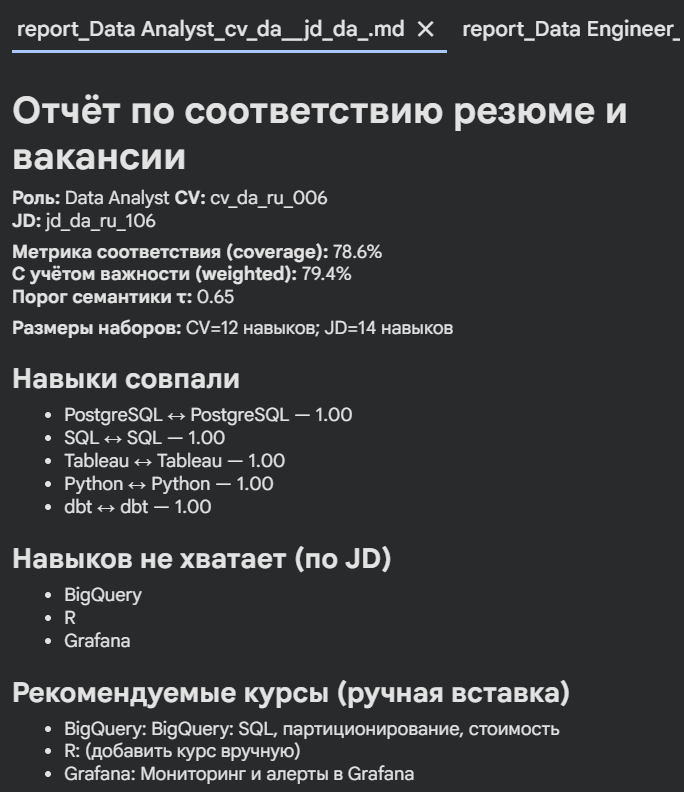

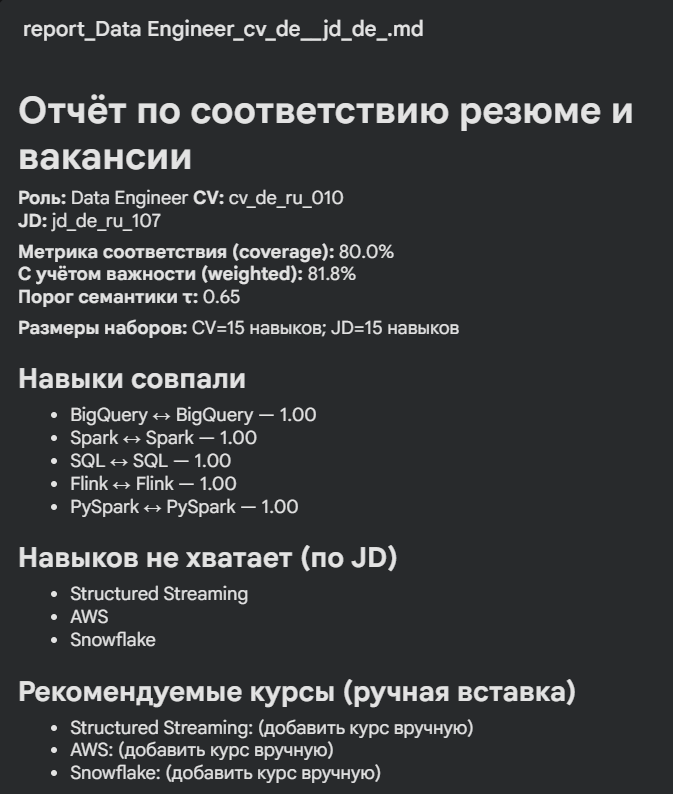

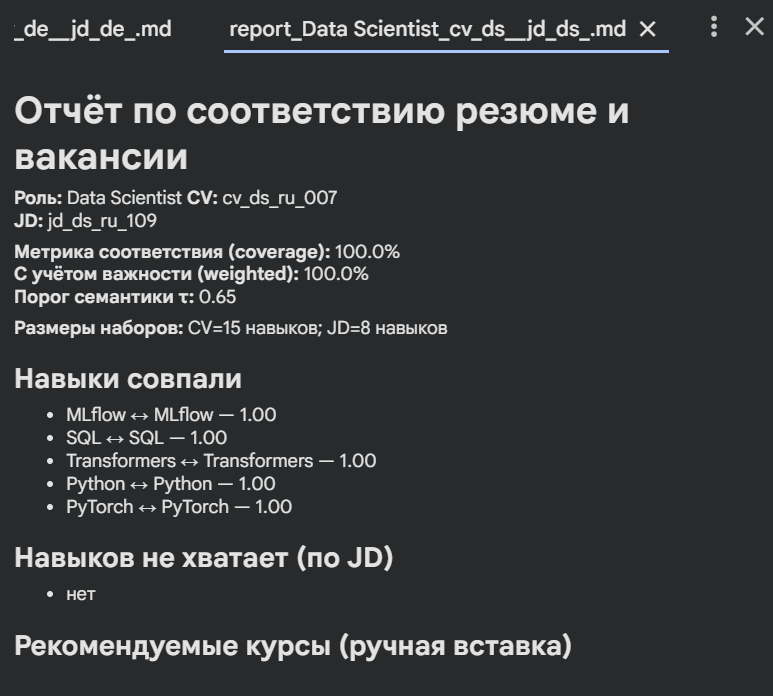